# EDA 01 — Target Variable Analysis

Deep dive into `Results` — the prediction target.
Key questions: distribution, class imbalance, binary vs ternary framing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

TARGET_COL = 'Results'
TARGET_COLORS = {'Pass': '#2ecc71', 'Fail': '#e74c3c', 'Pass w/ Conditions': '#f39c12'}

df = pd.read_parquet(DataLoader.processed('train.parquet'))
print('Train shape:', df.shape)

Train shape: (137176, 26)


## 1 · Target distribution

In [2]:
counts = df[TARGET_COL].value_counts()
pcts = df[TARGET_COL].value_counts(normalize=True).mul(100).round(2)
target_df = pd.DataFrame({'count': counts, 'pct': pcts})
print(f'Unique labels: {df[TARGET_COL].nunique()}')
print(f'Null targets:  {df[TARGET_COL].isna().sum()}')
target_df

Unique labels: 3
Null targets:  0


,count,pct
Results,,
Pass,91990,67.06
Fail,30320,22.1
Pass w/ Conditions,14866,10.84


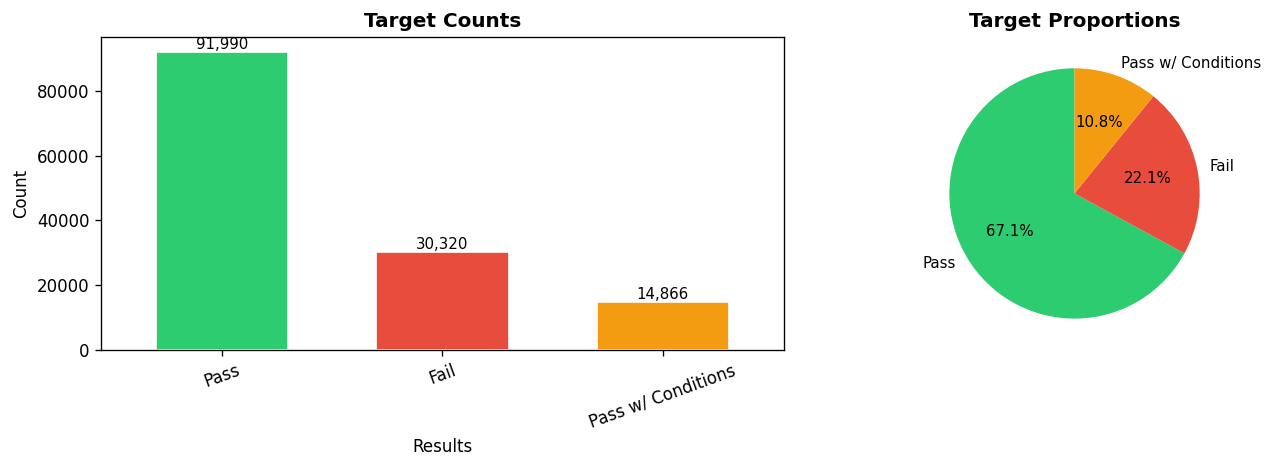

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = [TARGET_COLORS.get(x, '#95a5a6') for x in counts.index]
counts.plot.bar(ax=axes[0], color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Target Counts', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
pcts.plot.pie(ax=axes[1], colors=colors, autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 9})
axes[1].set_ylabel('')
axes[1].set_title('Target Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

## 2 · Class imbalance assessment

In [4]:
majority = counts.max()
minority = counts.min()
print(f'Majority class:    {counts.idxmax()}  ({majority:,} rows)')
print(f'Minority class:    {counts.idxmin()}  ({minority:,} rows)')
print(f'Imbalance ratio:   {majority / minority:.2f} : 1')
print()
print('Per-class ratios relative to majority:')
for label, cnt in counts.items():
    print(f'  {label:25s}  {cnt / majority:.3f}')

Majority class:    Pass  (91,990 rows)
Minority class:    Pass w/ Conditions  (14,866 rows)
Imbalance ratio:   6.19 : 1

Per-class ratios relative to majority:
  Pass                       1.000
  Fail                       0.330
  Pass w/ Conditions         0.162


## 3 · Binary vs ternary framing

Should we predict 3 classes (Pass / Fail / Pass w/ Conditions) or collapse to binary?

Common options:
- **Ternary**: keep all three — more nuanced but harder to model
- **Binary (strict)**: Pass vs Fail — drop Pass w/ Conditions
- **Binary (lenient)**: merge Pass w/ Conditions into Pass
- **Binary (strict-fail)**: merge Pass w/ Conditions into Fail

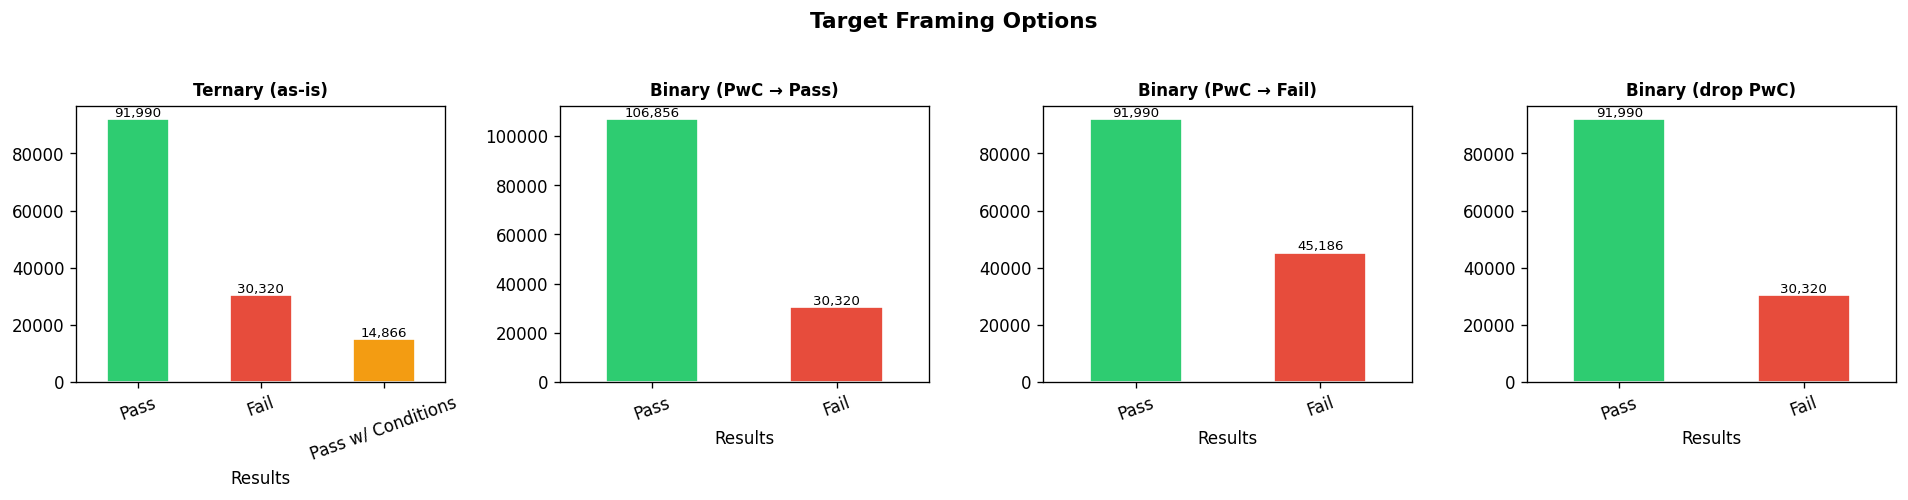

In [5]:
framings = {}

# Option A: ternary (as-is)
framings['Ternary (as-is)'] = df[TARGET_COL].value_counts()

# Option B: binary — merge PwC into Pass
binary_lenient = df[TARGET_COL].replace({'Pass w/ Conditions': 'Pass'})
framings['Binary (PwC → Pass)'] = binary_lenient.value_counts()

# Option C: binary — merge PwC into Fail
binary_strict = df[TARGET_COL].replace({'Pass w/ Conditions': 'Fail'})
framings['Binary (PwC → Fail)'] = binary_strict.value_counts()

# Option D: binary — drop PwC rows
binary_drop = df.loc[df[TARGET_COL] != 'Pass w/ Conditions', TARGET_COL]
framings['Binary (drop PwC)'] = binary_drop.value_counts()

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, (title, vc) in zip(axes, framings.items()):
    bar_colors = [TARGET_COLORS.get(x, '#95a5a6') for x in vc.index]
    vc.plot.bar(ax=ax, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=20)
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

fig.suptitle('Target Framing Options', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [6]:
# Summary table
summary_rows = []
for title, vc in framings.items():
    summary_rows.append({
        'Framing': title,
        'Classes': len(vc),
        'Total rows': vc.sum(),
        'Majority class': vc.idxmax(),
        'Majority pct': f'{vc.max() / vc.sum() * 100:.1f}%',
        'Imbalance ratio': f'{vc.max() / vc.min():.2f} : 1',
    })
pd.DataFrame(summary_rows).set_index('Framing')

,Classes,Total rows,Majority class,Majority pct,Imbalance ratio
Framing,,,,,
Ternary (as-is),3,137176,Pass,67.1%,6.19 : 1
Binary (PwC → Pass),2,137176,Pass,77.9%,3.52 : 1
Binary (PwC → Fail),2,137176,Pass,67.1%,2.04 : 1
Binary (drop PwC),2,122310,Pass,75.2%,3.03 : 1


## 4 · Takeaways

Document your decision here after reviewing the above:

- **Chosen framing**: _[fill in after analysis]_
- **Rationale**: _[fill in]_
- **Imbalance handling**: _[e.g. class weights, SMOTE, stratified sampling]_